# Best Model So Far

## Random Forest

In [14]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score
import seaborn as sns


In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [3]:
X = X.drop(columns=['AnyHealthcare', 'NoDocbcCost', 'Income', 'Education', 'HighChol', 'CholCheck', 'PhysHlth', 'HvyAlcoholConsump'])
X.head()

,HighBP,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,MentHlth,DiffWalk,Sex,Age
0,1,40,1,0,0,0,0,1,5,18,1,0,9
1,0,25,1,0,0,1,0,0,3,0,0,0,7
2,1,28,0,0,0,0,1,0,5,30,1,0,9
3,1,27,0,0,0,1,1,1,2,0,0,0,11
4,1,24,0,0,0,1,1,1,2,3,0,0,11


In [4]:
y.head()

,Diabetes_binary
0,0
1,0
2,0
3,0
4,0


In [5]:
# Save column names for later use
feature_names = X.columns.tolist()

## Model Development

In [6]:
X = X.to_numpy()
y = y.to_numpy().ravel()

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [21]:
def binary_classification_metrics(y_true, y_pred, y_prob=None):
    """
    Compute common binary classification metrics.
    
    Parameters:
    - y_true: array-like of shape (n_samples,), true binary labels (0 or 1)
    - y_pred: array-like of shape (n_samples,), predicted binary labels (0 or 1)
    - y_prob: array-like of shape (n_samples,), predicted probabilities for class 1
    
    Returns:
    - metrics: dict of all computed metrics
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Metrics calculations
    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)  # same as recall or TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = precision_score(y_true, y_pred)  # Positive Predictive Value
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = f1_score(y_true, y_pred)
    
    metrics = {
        'accuracy': accuracy,
        'sensitivity (recall, TPR)': sensitivity,
        'specificity (TNR)': specificity,
        'PPV (precision)': ppv,
        'NPV': npv,
        'F1': f1
    }
    
    # AUROC
    if y_prob is not None:
        try:
            auroc = roc_auc_score(y_true, y_prob[:,1])
        except ValueError:
            auroc = None
        try:
            auprc = average_precision_score(y_true, y_prob[:,1])
        except ValueError:
            auprc = None
        metrics['AUROC'] = auroc
        metrics['AUPRC'] = auprc
    
    return metrics

## Random forest

In [9]:
forest = RandomForestClassifier(
    n_estimators=600,
    max_depth=15,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

In [10]:
print(y.shape)

(253680,)


In [11]:
# Train model

forest.fit(X_train, y_train)

# Predict on test set
y_pred = forest.predict(X_test)




Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.74      0.83     43667
           1       0.31      0.74      0.44      7069

    accuracy                           0.74     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.74      0.77     50736



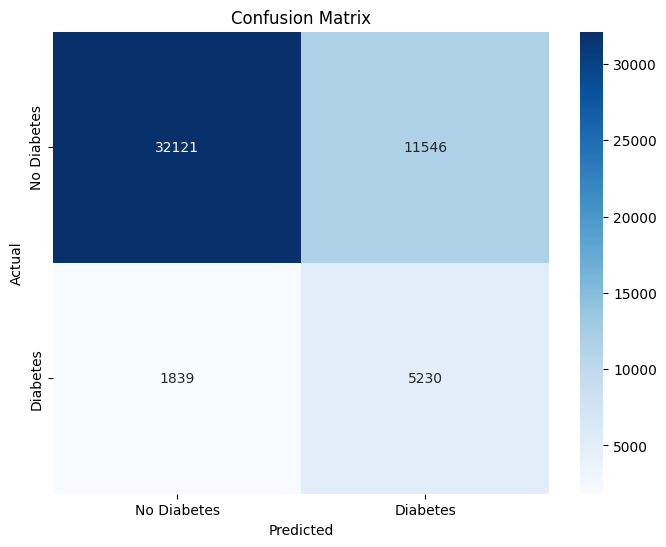

In [12]:
# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

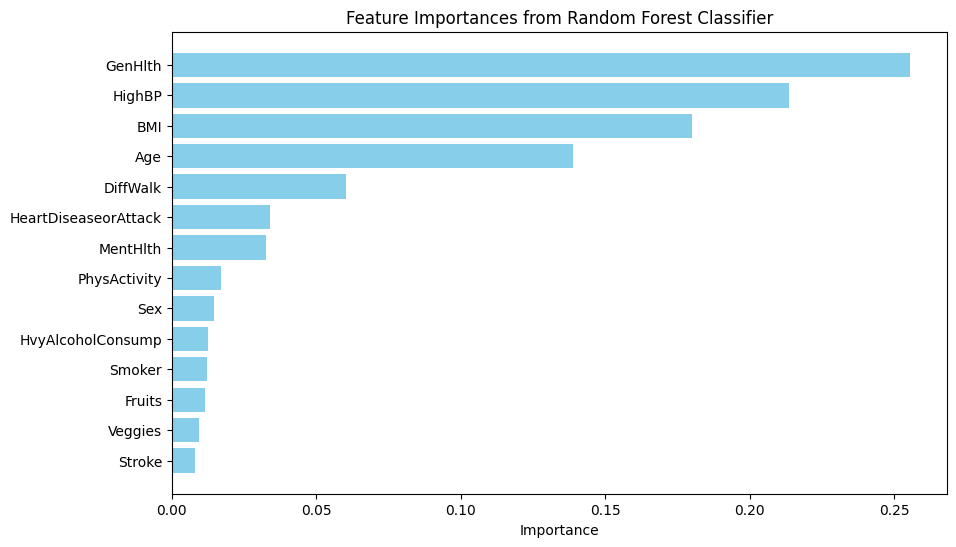

In [13]:
importances = forest.feature_importances_
assert len(feature_names) == len(importances)

feature_importance_df = pd.DataFrame({"Feature": feature_names,
                                      "Importance": importances}) \
                          .sort_values("Importance", ascending=True)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importances from Random Forest Classifier")
plt.show()

## HistGradientBoosting

In [34]:
hist = HistGradientBoostingClassifier(
    random_state=42,
    max_iter=600,            
    learning_rate=0.05,      
    max_leaf_nodes=31,
    min_samples_leaf=10,     
    early_stopping='auto',
    class_weight='balanced'  
)

hist.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,600
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,10
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [35]:
y_pred_hist = hist.predict(X_test)
y_prob_hist = hist.predict_proba(X_test)

metrics = binary_classification_metrics(y_test, y_pred_hist, y_prob_hist)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

accuracy: 0.7102
sensitivity (recall, TPR): 0.7877
specificity (TNR): 0.6977
PPV (precision): 0.2966
NPV: 0.9530
F1: 0.4310
AUROC: 0.8171
AUPRC: 0.4040



Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     43667
           1       0.55      0.13      0.22      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.56      0.57     50736
weighted avg       0.83      0.86      0.83     50736



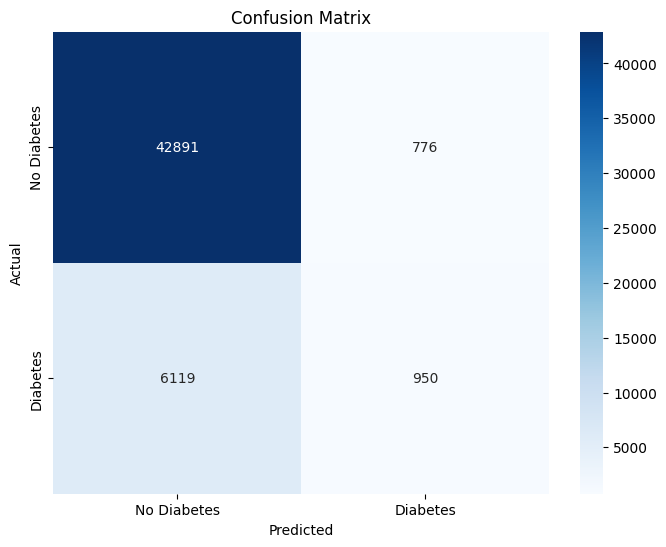

In [26]:
# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_hist))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_hist)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [37]:
import joblib

joblib.dump(hist, 'hgb_classifier_V2.pkl')

['hgb_classifier_V2.pkl']

## Decision Tree

In [25]:
tree = DecisionTreeClassifier(
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.71      0.81     43667
           1       0.28      0.71      0.40      7069

    accuracy                           0.71     50736
   macro avg       0.61      0.71      0.60     50736
weighted avg       0.85      0.71      0.75     50736



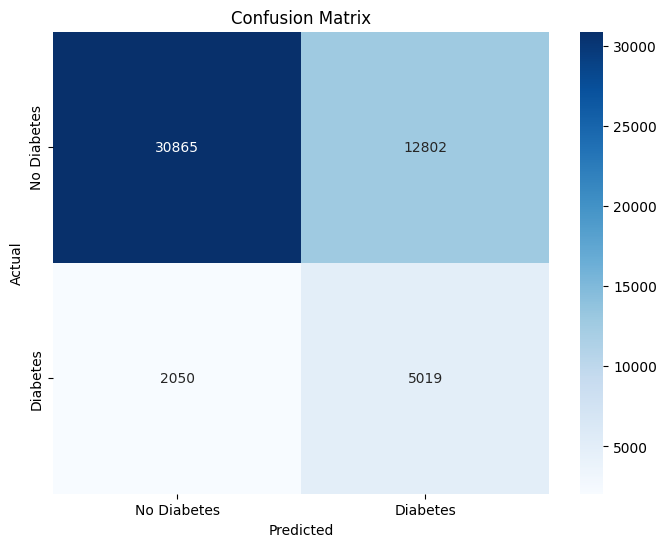

In [26]:
# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

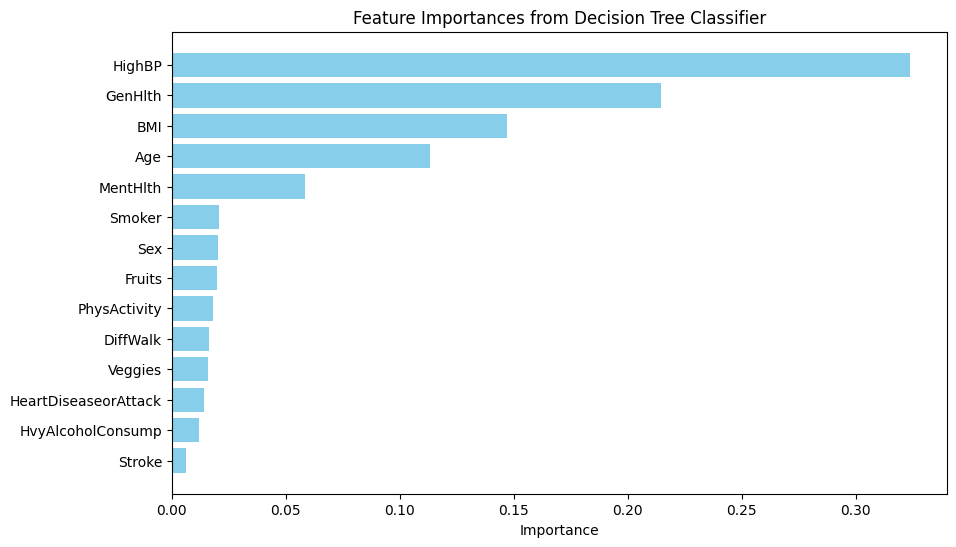

In [27]:
importances = tree.feature_importances_
assert len(feature_names) == len(importances)

feature_importance_df = pd.DataFrame({"Feature": feature_names,
                                      "Importance": importances}) \
                          .sort_values("Importance", ascending=True)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importances from Decision Tree Classifier")
plt.show()

My concern with this is that it does not bring enough value for the costumer, if it mostly uses age, high blood pressure and BMI to predict who needs diabetes screening, a simple rule based tool might be equally good, and a lot cheaper to implement.